# 03 — Characterising the knowledge/behaviour dissociation

Notebook 02 found Llama 3.1 8B *represents* answerability almost perfectly (~97% linear probe) but *acts* on it far less reliably (~74%). This notebook characterises that gap: in the failure cases — **unanswerable questions the model answered anyway** — what is different about the activations?

**Inputs:** `acts_layer_{i}.pt`, `labels.csv`, `probe_accuracy_answerable.csv` (results dir — run notebook 02 first).
**Outputs:** `figures/quadrant_distributions.png`, `results/conditional_probe_accuracies.csv`, `figures/conditional_vs_answerability.png`.

No GPU needed — runs on the cached activations.

In [2]:
# --- Colab setup (skip these two lines when running locally) ---
from google.colab import drive; drive.mount('/content/drive')
%cd "/content/drive/Othercomputers/My MacBook Air/abstention-geometry"
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

Mounted at /content/drive
/content/drive/Othercomputers/My MacBook Air/abstention-geometry


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.paths import results_dir
from src.probes import load_activations, difference_of_means, train_conditional_probe
from src.dissociation import QUADRANTS, assign_quadrants, project_onto_direction

In [4]:
import src

REPO_ROOT = Path(src.__file__).resolve().parent.parent
RESULTS_DIR = results_dir()
FIG_DIR = REPO_ROOT / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)
PEAK_LAYER = 15  # answerability probe saturates here (notebook 02)
print('RESULTS_DIR =', RESULTS_DIR)

RESULTS_DIR = /content/drive/Othercomputers/My MacBook Air/abstention-geometry/results/


## Step 1 — split the data into four quadrants

(gold answerability x judged behaviour). The quadrant of interest is **`unanswerable_answered`** — the model 'knew' the question was unanswerable but answered anyway.

In [5]:
acts_by_layer = load_activations(RESULTS_DIR)
layers = sorted(acts_by_layer.keys())
ldf = pd.read_csv(RESULTS_DIR + 'labels.csv')
assert len(ldf) == acts_by_layer[layers[0]].shape[0], 'labels and activations are misaligned'

ldf['quadrant'] = assign_quadrants(ldf)
print(ldf['quadrant'].value_counts())
print('\nunanswerable_answered = the failure cases (model knew but answered anyway)')

quadrant
answerable_answered       1696
unanswerable_answered      780
answerable_abstained       641
unanswerable_abstained     252
Name: count, dtype: int64

unanswerable_answered = the failure cases (model knew but answered anyway)


## Step 2 — project onto the answerability direction

At the peak layer, take the answerability difference-of-means vector and project every activation onto it. If the dissociation is *not* random, the failure cases (`unanswerable_answered`) should sit closer to the answerable side than correct abstentions (`unanswerable_abstained`) — i.e. the model's internal signal was genuinely weaker there.

In [6]:
# Answerability direction at the peak layer (difference of means, all data).
answerable = ldf['answerable'].astype(int).to_numpy()
direction = difference_of_means(acts_by_layer[PEAK_LAYER], answerable)

# Scalar projection of every activation onto that direction.
ldf['projection'] = project_onto_direction(acts_by_layer[PEAK_LAYER], direction)

print(f'mean projection onto the answerability direction at layer {PEAK_LAYER}')
print('(higher = further toward the answerable side)\n')
print(ldf.groupby('quadrant')['projection'].agg(['count', 'mean', 'std']))

mean projection onto the answerability direction at layer 15
(higher = further toward the answerable side)

                        count      mean       std
quadrant                                         
answerable_abstained      641  1.555119  0.943870
answerable_answered      1696  1.433490  1.114029
unanswerable_abstained    252 -1.472262  1.242493
unanswerable_answered     780 -1.818842  1.053074


## Step 3 — quadrant distributions on the answerability axis

Do the two `unanswerable_*` groups separate, or overlap? Separation means the failure cases carry a measurably weaker answerability signal.

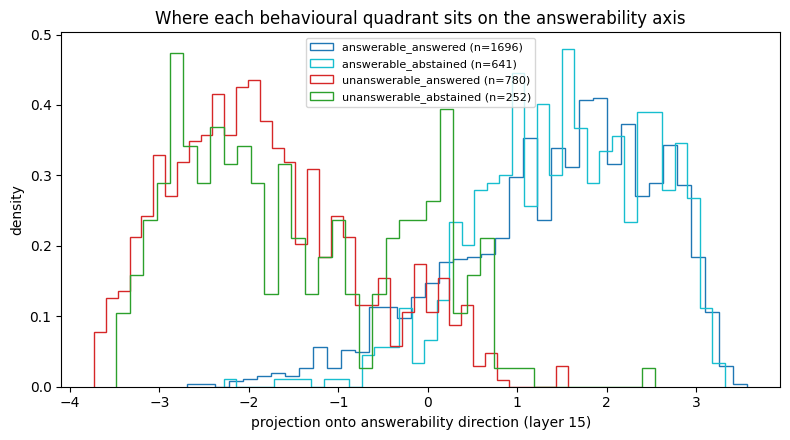

In [7]:
colors = {
    'answerable_answered':    'tab:blue',
    'answerable_abstained':   'tab:cyan',
    'unanswerable_abstained': 'tab:green',
    'unanswerable_answered':  'tab:red',
}

fig, ax = plt.subplots(figsize=(8, 4.5))
for quad in QUADRANTS:
    vals = ldf.loc[ldf['quadrant'] == quad, 'projection']
    ax.hist(vals, bins=40, density=True, histtype='step', lw=2,
            color=colors[quad], label=f'{quad} (n={len(vals)})')
ax.set_xlabel(f'projection onto answerability direction (layer {PEAK_LAYER})')
ax.set_ylabel('density')
ax.set_title('Where each behavioural quadrant sits on the answerability axis')
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / 'quadrant_distributions.png', dpi=150)
plt.show()

## Step 4 — conditional behavioural probe

Restrict to **unanswerable questions only** and train a probe to predict the behavioural outcome (answered vs abstained). This holds answerability fixed and asks how decodable the *decision* is on its own.

In [8]:
# Unanswerable subset; behaviour = 1 if the model answered (the failure), 0 if abstained.
unanswerable = ~ldf['answerable'].astype(bool).to_numpy()
behaviour = (ldf['judge_label'] == 'answered').astype(int).to_numpy()

cond_df = train_conditional_probe(acts_by_layer, behaviour, mask=unanswerable)
cond_df.to_csv(RESULTS_DIR + 'conditional_probe_accuracies.csv', index=False)

peak = cond_df.loc[cond_df['mean_balanced_accuracy'].idxmax()]
print(f"conditional probe trained on {int(cond_df['n_samples'][0])} unanswerable questions")
print(f"peak layer {int(peak['layer'])} | balanced accuracy {peak['mean_balanced_accuracy']:.3f}")

conditional probe trained on 1032 unanswerable questions
peak layer 30 | balanced accuracy 0.737


## Step 5 — conditional behaviour vs. answerability knowledge

The two curves on one axes. The gap quantifies how much harder it is to predict what the model *does* than what it *knows*.

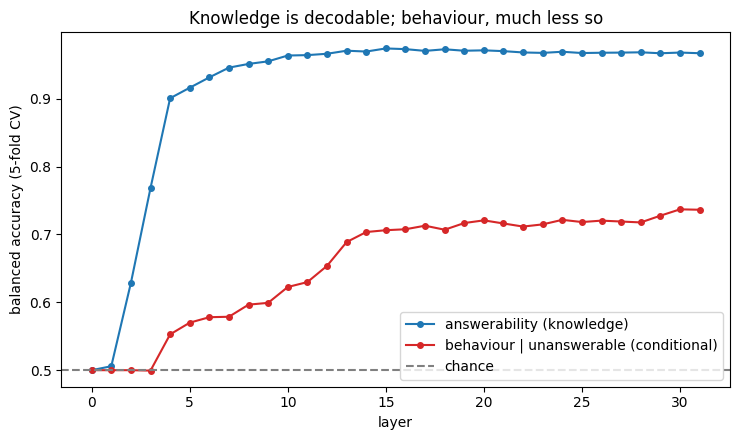

peak answerability : 0.974
peak conditional   : 0.737
dissociation gap   : 0.237


In [9]:
ans_df = pd.read_csv(RESULTS_DIR + 'probe_accuracy_answerable.csv')

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(ans_df['layer'], ans_df['mean_balanced_accuracy'], marker='o', ms=4,
        color='tab:blue', label='answerability (knowledge)')
ax.plot(cond_df['layer'], cond_df['mean_balanced_accuracy'], marker='o', ms=4,
        color='tab:red', label='behaviour | unanswerable (conditional)')
ax.axhline(0.5, ls='--', color='gray', label='chance')
ax.set_xlabel('layer'); ax.set_ylabel('balanced accuracy (5-fold CV)')
ax.set_title('Knowledge is decodable; behaviour, much less so')
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / 'conditional_vs_answerability.png', dpi=150)
plt.show()

gap = ans_df['mean_balanced_accuracy'].max() - cond_df['mean_balanced_accuracy'].max()
print(f"peak answerability : {ans_df['mean_balanced_accuracy'].max():.3f}")
print(f"peak conditional   : {cond_df['mean_balanced_accuracy'].max():.3f}")
print(f"dissociation gap   : {gap:.3f}")